# Modèle 3 — Détection d'Anomalies

Entraîne et sauvegarde deux détecteurs non supervisés :

| modèle | entrée | ce qu'il détecte | sortie |
|--------|--------|------------------|--------|
| **Isolation Forest** | vecteur de 6 caractéristiques par trajet | trajets globalement atypiques | `anomaly_if.pkl` |
| **Autoencodeur LSTM** | séquence arrêt par arrêt (30 × 3) | *où* l'anomalie s'est produite | `anomaly_lstm.pt` |

Modifiez le bloc **Config** pour ajuster les seuils et hyperparamètres.

In [18]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, torch
from IPython.display import display

from src.data import anomaly as an

print('imports OK')

imports OK


In [ ]:
# Config — modifiez ici 
# Isolation Forest
IF_N_ESTIMATORS   = 200     # arbres (plus = plus stable, plus lent)
IF_CONTAMINATION  = 0.05    # fraction supposée d'anomalies (~5 %)
IF_RANDOM_STATE   = 42

# Autoencodeur LSTM
LSTM_SEQ_LEN  = 30          # arrêts par séquence (complété/tronqué)
LSTM_HIDDEN   = 32          # dimension de l'encodage latent
LSTM_LAYERS   = 1
LSTM_EPOCHS   = 10          # augmenter à 20-30 pour de meilleures performances
LSTM_LR       = 1e-3
LSTM_BATCH    = 128
LSTM_THRESHOLD_PCT = 95     # percentile pour le seuil d'anomalie

# Chemins
ROOT       = Path.cwd().parents[1]
FOUNDATION = ROOT / 'data' / 'processed' / 'foundation_arrivals_full.parquet'
MODELS_DIR = ROOT / 'models' / 'anomaly'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'foundation : {FOUNDATION.name}  existe={FOUNDATION.exists()}')

foundation : foundation_arrivals_full.parquet  existe=True


In [20]:
# Charger les données de fondation
fa = pd.read_parquet(FOUNDATION)
fa['trip_start'] = pd.to_datetime(fa['trip_start'])
fa['arrival']    = pd.to_datetime(fa['arrival'])
fa['departure']  = pd.to_datetime(fa['departure'])

CFG = an.AnomalyConfig(
    if_n_estimators=IF_N_ESTIMATORS,
    if_contamination=IF_CONTAMINATION,
    lstm_hidden=LSTM_HIDDEN,
    lstm_epochs=LSTM_EPOCHS,
    lstm_lr=LSTM_LR,
    lstm_batch=LSTM_BATCH,
    seq_pad=LSTM_SEQ_LEN,
)
print(f'foundation : {len(fa):,} lignes | {fa["trip_id"].nunique()} trip_id uniques | '
      f'dwell_s disponible : {fa["dwell_s"].notna().sum():,} arrêts')

foundation : 168,481 lignes | 24 trip_id uniques | dwell_s disponible : 128,882 arrêts


In [21]:
# Construire la matrice de caractéristiques par trajet
trips = an.trip_features(fa, CFG)

print(f'trajets : {len(trips):,} | lignes : {trips["line"].nunique()} | '
      f'compagnies : {trips["societe"].nunique()}')
print(f'caractéristiques : {an.FEATURES}')
display(trips[an.FEATURES].describe().round(1))

trajets : 17,565 | lignes : 25 | compagnies : 3
caractéristiques : ['n_stops', 'match_rate', 'max_dwell_s', 'mean_dwell_s', 'total_elapsed', 'dist_m_max']


,n_stops,match_rate,max_dwell_s,mean_dwell_s,total_elapsed,dist_m_max
count,17565.0,17565.0,17565.0,17565.0,17565.0,17565.0
mean,7.2,1.0,523.2,130.6,72.7,125.3
std,4.9,0.0,741.9,123.1,88.1,76.8
min,3.0,1.0,0.0,0.0,2.6,5.0
25%,5.0,1.0,120.0,61.6,30.2,52.0
50%,6.0,1.0,265.4,92.0,39.8,134.0
75%,6.0,1.0,715.0,167.0,56.2,180.0
max,32.0,1.0,31690.0,5409.2,989.4,349.0


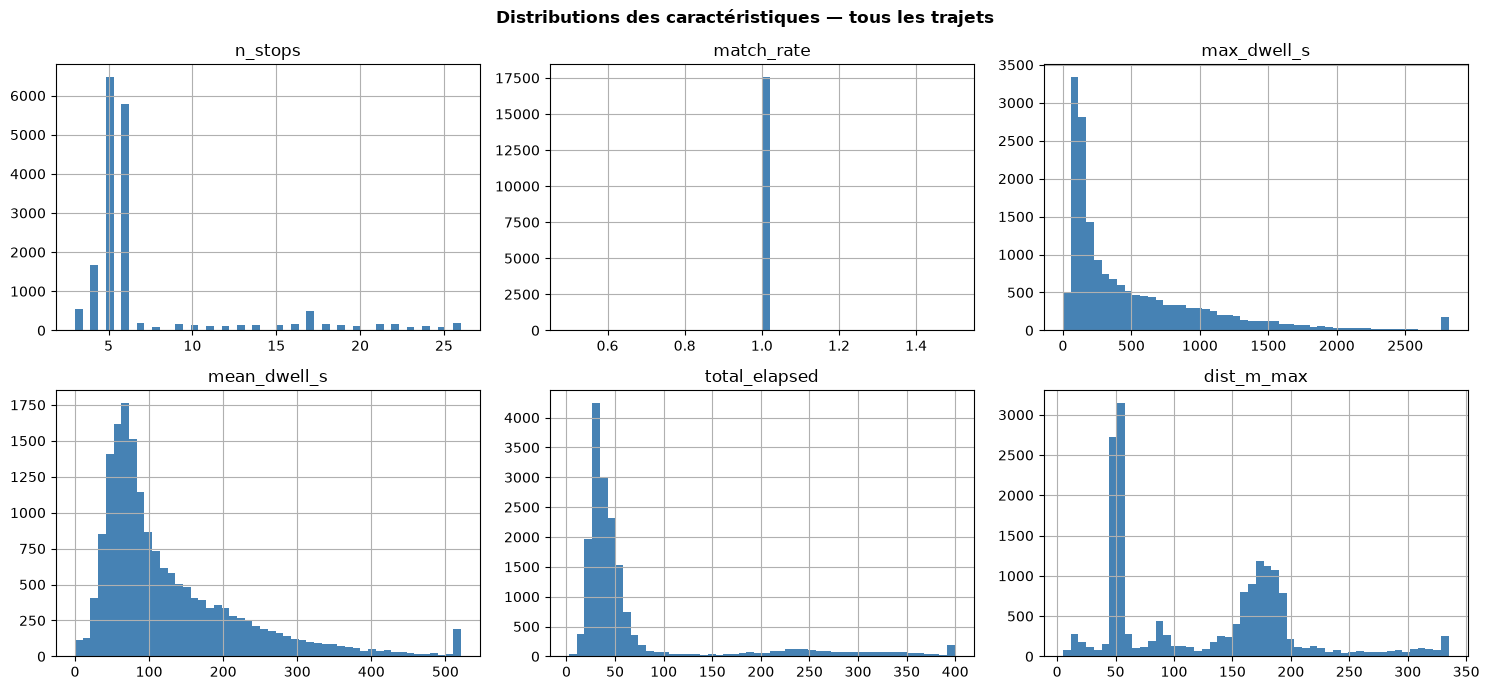

In [22]:
# Distributions des caractéristiques (aperçu avant entraînement)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Distributions des caractéristiques — tous les trajets', fontweight='bold')

for ax, feat in zip(axes.flat, an.FEATURES):
    q99 = trips[feat].quantile(0.99)
    trips[feat].clip(upper=q99).hist(bins=50, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(feat); ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [23]:
# Entraîner l'Isolation Forest
if_model, if_mean, if_std = an.train_isolation_forest(trips, CFG)
trips_scored = an.score_trips(if_model, if_mean, if_std, trips)

n_anom = trips_scored['anomaly'].sum()
print(f'Isolation Forest entraîné ✓')
print(f'  n_estimators={IF_N_ESTIMATORS} | contamination={IF_CONTAMINATION}')
print(f'  trajets anormaux signalés : {n_anom} / {len(trips_scored)} ({100*n_anom/len(trips_scored):.1f}%)')

Isolation Forest entraîné ✓
  n_estimators=200 | contamination=0.05
  trajets anormaux signalés : 879 / 17565 (5.0%)


In [ ]:
# Grid Search — Isolation Forest
from sklearn.ensemble import IsolationForest
import itertools

X_raw = trips[an.FEATURES].values.astype(float)
X_s, if_base_mean, if_base_std = an._scale(X_raw)

if_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [0.5, 0.75, 1.0],
    'contamination': [0.03, 0.05, 0.08],
}

if_results = []
combos_if = list(itertools.product(
    if_param_grid['n_estimators'],
    if_param_grid['max_features'],
    if_param_grid['contamination'],
))
print(f'Testing {len(combos_if)} Isolation Forest configs '
      f'({len(if_param_grid["n_estimators"])} × '
      f'{len(if_param_grid["max_features"])} × '
      f'{len(if_param_grid["contamination"])}) ...\n')

for n_est, max_feat, contam in combos_if:
    clf = IsolationForest(n_estimators=n_est, max_features=max_feat,
                          contamination=contam, random_state=42, n_jobs=-1)
    clf.fit(X_s)
    scores   = clf.score_samples(X_s)
    n_anom   = int((clf.predict(X_s) == -1).sum())
    sc_range = float(scores.max() - scores.min())
    if_results.append({
        'n_estimators': n_est, 'max_features': max_feat, 'contamination': contam,
        'n_anomalies': n_anom, 'score_range': sc_range, 'model': clf,
    })

if_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in if_results])
if_df_sorted = if_df.sort_values('score_range', ascending=False)
print('Top-5 configs (score range ↑ = better separation):')
display(if_df_sorted.head(5).reset_index(drop=True))

best_if = if_df_sorted.iloc[0]
print(f'\nBest: n_estimators={int(best_if.n_estimators)}, '
      f'max_features={best_if.max_features}, contamination={best_if.contamination}')
print(f'  score_range={best_if.score_range:.4f}  n_anomalies={int(best_if.n_anomalies)}')

# Update models
best_if_idx = if_df['score_range'].idxmax()
if_model    = if_results[best_if_idx]['model']
if_mean     = if_base_mean
if_std      = if_base_std
trips_scored = an.score_trips(if_model, if_mean, if_std, trips)
n_anom = trips_scored['anomaly'].sum()
print(f'\nif_model updated ✓  →  {n_anom} anomalies ({100*n_anom/len(trips_scored):.1f}%)')

Testing 27 Isolation Forest configs (3 × 3 × 3) ...

Top-5 configs (score range ↑ = better separation):


,n_estimators,max_features,contamination,n_anomalies,score_range
0,100,1.0,0.08,1406,0.435598
1,100,1.0,0.05,879,0.435598
2,100,1.0,0.03,527,0.435598
3,300,1.0,0.03,527,0.429497
4,300,1.0,0.05,879,0.429497



Best: n_estimators=100, max_features=1.0, contamination=0.08
  score_range=0.4356  n_anomalies=1406

if_model updated ✓  →  527 anomalies (3.0%)


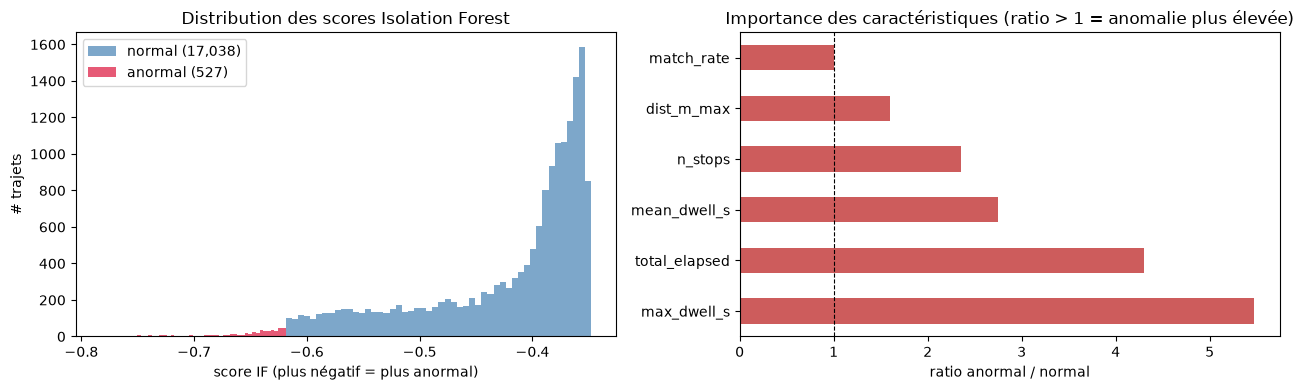

In [25]:
# Distribution des scores IF + importance des caractéristiques
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(trips_scored.loc[~trips_scored['anomaly'], 'if_score'],
           bins=50, alpha=0.7, color='steelblue', label=f'normal ({(~trips_scored["anomaly"]).sum():,})')
ax[0].hist(trips_scored.loc[ trips_scored['anomaly'], 'if_score'],
           bins=50, alpha=0.7, color='crimson',   label=f'anormal ({n_anom:,})')
ax[0].set_xlabel('score IF (plus négatif = plus anormal)')
ax[0].set_ylabel('# trajets'); ax[0].set_title('Distribution des scores Isolation Forest')
ax[0].legend()

feat_means = trips_scored.groupby('anomaly')[an.FEATURES].mean().T
feat_means.columns = ['normal', 'anormal']
ratio = (feat_means['anormal'] / feat_means['normal']).sort_values(ascending=False)
ratio.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].axvline(1, color='black', ls='--', lw=0.8)
ax[1].set_xlabel('ratio anormal / normal')
ax[1].set_title('Importance des caractéristiques (ratio > 1 = anomalie plus élevée)')
plt.tight_layout(); plt.show()

In [26]:
# Top 15 trajets les plus anormaux
top = (trips_scored[trips_scored['anomaly']]
       .sort_values('if_score')
       .head(15)[['day','line','societe','dir','n_stops','max_dwell_s','total_elapsed','if_score']])
top['max_dwell_s'] = top['max_dwell_s'].round(0).astype(int)
top['if_score']    = top['if_score'].round(3)
print('Top 15 trajets les plus anormaux (Isolation Forest) :')
display(top)

Top 15 trajets les plus anormaux (Isolation Forest) :


,day,line,societe,dir,n_stops,max_dwell_s,total_elapsed,if_score
11772,20251112,215,S.R.T.K,RETOUR,12,9892,366.847283,-0.783
5993,20250520,306,S.R.T.K,RETOUR,8,11400,626.172850,-0.781
4290,20250419,209,S.R.T.K,RETOUR,3,10799,319.993300,-0.774
567,20250201,215,S.R.T.K,ALLER,4,6000,359.983400,-0.774
15965,20260317,215,S.R.T.K,RETOUR,6,8464,353.901300,-0.773
10553,20251001,212,S.R.T.K,RETOUR,4,6188,326.464700,-0.771
15291,20260213,215,S.R.T.K,RETOUR,14,9704,467.329900,-0.769
16125,20260326,215,S.R.T.K,RETOUR,9,7030,413.015983,-0.768
8071,20250718,304,S.T.S,RETOUR,27,8610,475.964150,-0.765
17560,20260620,306,S.T.S,ALLER,25,12717,305.168917,-0.758


## Autoencodeur LSTM

Apprend la séquence normale arrêt par arrêt — les trajets avec une **erreur de reconstruction élevée**
sont ceux dont le profil d'arrêts n'a jamais été vu à l'entraînement.

In [27]:
# Construire les tenseurs de séquences
X, trip_ids = an.build_sequences(fa, CFG)

print(f'tenseur de séquences : {X.shape}  (trajets × arrêts × caractéristiques)')
print(f'caractéristiques : {an.SEQ_FEATURES}')

tenseur de séquences : (20184, 30, 3)  (trajets × arrêts × caractéristiques)
caractéristiques : ['dwell_s', 'dist_m', 'matched']


In [28]:
# Entraîner l'autoencodeur LSTM
lstm_model, train_errors = an.train_lstm_autoencoder(X, CFG)
threshold = float(np.percentile(train_errors, LSTM_THRESHOLD_PCT))
lstm_anom = train_errors > threshold

print(f'Autoencodeur LSTM entraîné ✓')
print(f'  hidden={LSTM_HIDDEN}, layers={LSTM_LAYERS}, epochs={LSTM_EPOCHS}')
print(f'  seuil ({LSTM_THRESHOLD_PCT}e percentile) : {threshold:.5f}')
print(f'  trajets anormaux LSTM : {lstm_anom.sum()} / {len(train_errors)} ({100*lstm_anom.mean():.1f}%)')

  époque 10/10  perte=0.01153
Autoencodeur LSTM entraîné ✓
  hidden=32, layers=1, epochs=10
  seuil (95e percentile) : 0.07668
  trajets anormaux LSTM : 1010 / 20184 (5.0%)


In [ ]:
# Grid Search — Autoencodeur LSTM
import itertools

lstm_ae_grid = {
    'hidden': [16, 32, 64],
    'epochs': [10, 20, 30],
}

ae_results = []
combos_ae = list(itertools.product(lstm_ae_grid['hidden'], lstm_ae_grid['epochs']))
print(f'Testing {len(combos_ae)} LSTM autoencoder configs ...\n')

for hidden, epochs in combos_ae:
    cfg_tmp = an.AnomalyConfig(
        lstm_hidden=hidden,
        lstm_epochs=epochs,
        lstm_lr=1e-3,
        lstm_batch=LSTM_BATCH,
        seq_pad=LSTM_SEQ_LEN,
    )
    m, errs = an.train_lstm_autoencoder(X, cfg_tmp)
    thr      = float(np.percentile(errs, LSTM_THRESHOLD_PCT))
    n_anom_  = int((errs > thr).sum())
    ae_results.append({
        'hidden': hidden, 'epochs': epochs,
        'mean_err': float(errs.mean()), 'std_err': float(errs.std()),
        'threshold': thr, 'n_anomalies': n_anom_, 'model': m, 'errors': errs,
    })
    print(f'  hidden={hidden:2d}  epochs={epochs:2d}  '
          f'→  mean_err={errs.mean():.5f}  thr={thr:.5f}  n_anom={n_anom_}')

ae_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'errors')}
                       for r in ae_results])
ae_df_sorted = ae_df.sort_values('mean_err')
print('\nTop-5 LSTM AE configs (mean_err ↓ = better):')
display(ae_df_sorted.head(5).reset_index(drop=True))

best_ae     = ae_df_sorted.iloc[0]
best_ae_idx = ae_df['mean_err'].idxmin()
print(f'\nBest: hidden={int(best_ae.hidden)}, epochs={int(best_ae.epochs)}'
      f'  →  mean_err={best_ae.mean_err:.5f}  n_anom={int(best_ae.n_anomalies)}')

# Update model variables used by downstream cells
lstm_model   = ae_results[best_ae_idx]['model']
train_errors = ae_results[best_ae_idx]['errors']
threshold    = ae_results[best_ae_idx]['threshold']
lstm_anom    = train_errors > threshold
print('\nlstm_model updated ✓  (best LSTM autoencoder from grid search)')

Testing 9 LSTM autoencoder configs ...

  époque 10/10  perte=0.01406
  hidden=16  epochs=10  →  mean_err=0.01379  thr=0.07795  n_anom=1010
  époque 10/20  perte=0.01397
  époque 20/20  perte=0.01252
  hidden=16  epochs=20  →  mean_err=0.01234  thr=0.07602  n_anom=1010
  époque 10/30  perte=0.01309
  époque 20/30  perte=0.01113
  époque 30/30  perte=0.01007
  hidden=16  epochs=30  →  mean_err=0.01002  thr=0.06169  n_anom=1010
  époque 10/10  perte=0.01259
  hidden=32  epochs=10  →  mean_err=0.01230  thr=0.06841  n_anom=1010
  époque 10/20  perte=0.01237
  époque 20/20  perte=0.01011
  hidden=32  epochs=20  →  mean_err=0.01010  thr=0.06173  n_anom=1010
  époque 10/30  perte=0.01233
  époque 20/30  perte=0.01012
  époque 30/30  perte=0.00904
  hidden=32  epochs=30  →  mean_err=0.00896  thr=0.05761  n_anom=1010
  époque 10/10  perte=0.01009
  hidden=64  epochs=10  →  mean_err=0.01001  thr=0.05829  n_anom=1010
  époque 10/20  perte=0.01038
  époque 20/20  perte=0.00859
  hidden=64  epochs=

,hidden,epochs,mean_err,std_err,threshold,n_anomalies
0,64,30,0.007617,0.017691,0.048122,1010
1,64,20,0.008180,0.018763,0.052964,1010
2,32,30,0.008957,0.020401,0.057606,1010
3,64,10,0.010009,0.020488,0.058288,1010
4,16,30,0.010019,0.021150,0.061690,1010



Best: hidden=64, epochs=30  →  mean_err=0.00762  n_anom=1010

lstm_model updated ✓  (best LSTM autoencoder from grid search)


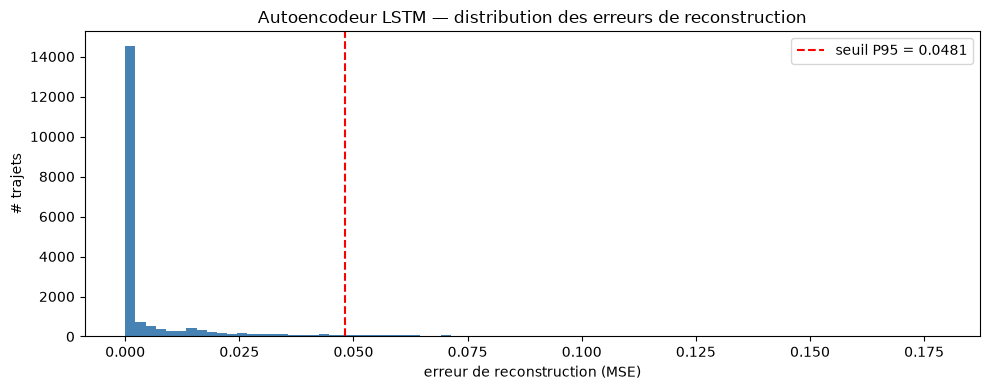

In [30]:
# Distribution des erreurs de reconstruction
plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=80, color='steelblue', edgecolor='none')
plt.axvline(threshold, color='red', ls='--', lw=1.5,
            label=f'seuil P{LSTM_THRESHOLD_PCT} = {threshold:.4f}')
plt.xlabel('erreur de reconstruction (MSE)'); plt.ylabel('# trajets')
plt.title('Autoencodeur LSTM — distribution des erreurs de reconstruction')
plt.legend(); plt.tight_layout(); plt.show()

Accord IF vs LSTM : 93.1%
Signalés par les DEUX modèles : 145 trajets (plus haute confiance)


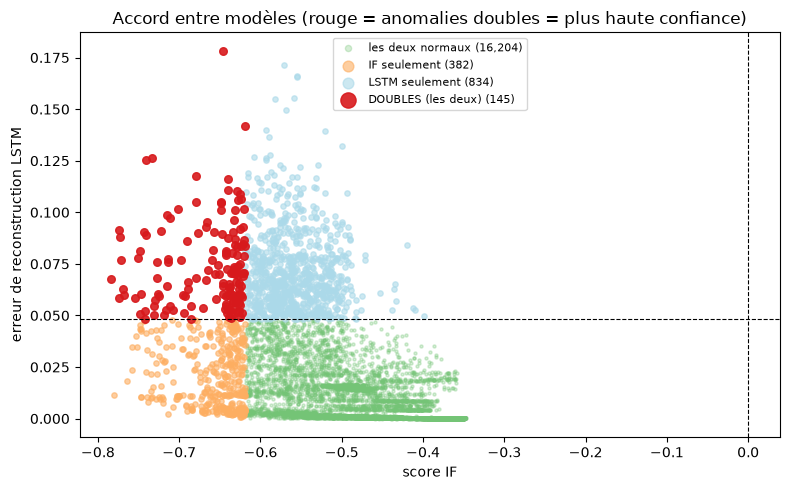

In [31]:
# Accord entre IF et LSTM
id_cols = list(an.TRIP_KEYS)
id_df = pd.DataFrame(trip_ids, columns=id_cols)
id_df['lstm_anom'] = lstm_anom
id_df['lstm_err']  = train_errors
merged = trips_scored.merge(id_df, on=id_cols, how='inner')

agree = (merged['anomaly'] == merged['lstm_anom']).mean()
both  = (merged['anomaly'] & merged['lstm_anom']).sum()
print(f'Accord IF vs LSTM : {100*agree:.1f}%')
print(f'Signalés par les DEUX modèles : {both} trajets (plus haute confiance)')

fig, ax = plt.subplots(figsize=(8, 5))
groups = [
    (~merged['anomaly'] & ~merged['lstm_anom'], 'les deux normaux',  '#74c476', 5,  0.3),
    ( merged['anomaly'] & ~merged['lstm_anom'], 'IF seulement',      '#fdae61', 15, 0.6),
    (~merged['anomaly'] &  merged['lstm_anom'], 'LSTM seulement',    '#abd9e9', 15, 0.6),
    ( merged['anomaly'] &  merged['lstm_anom'], 'DOUBLES (les deux)','#d7191c', 30, 0.9),
]
for mask, label, color, sz, al in groups:
    ax.scatter(merged[mask]['if_score'], merged[mask]['lstm_err'],
               s=sz, alpha=al, color=color, label=f'{label} ({mask.sum():,})')
ax.axvline(0,         color='black', ls='--', lw=0.8)
ax.axhline(threshold, color='black', ls='--', lw=0.8)
ax.set_xlabel('score IF'); ax.set_ylabel('erreur de reconstruction LSTM')
ax.set_title('Accord entre modèles (rouge = anomalies doubles = plus haute confiance)')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()

Trajet le plus anormal (LSTM) : {'day': '20251017', 'line': '304', 'societe': 'S.T.S', 'bus': np.int64(788), 'trip_id': np.int64(0)}
  erreur de reconstruction : 0.17832


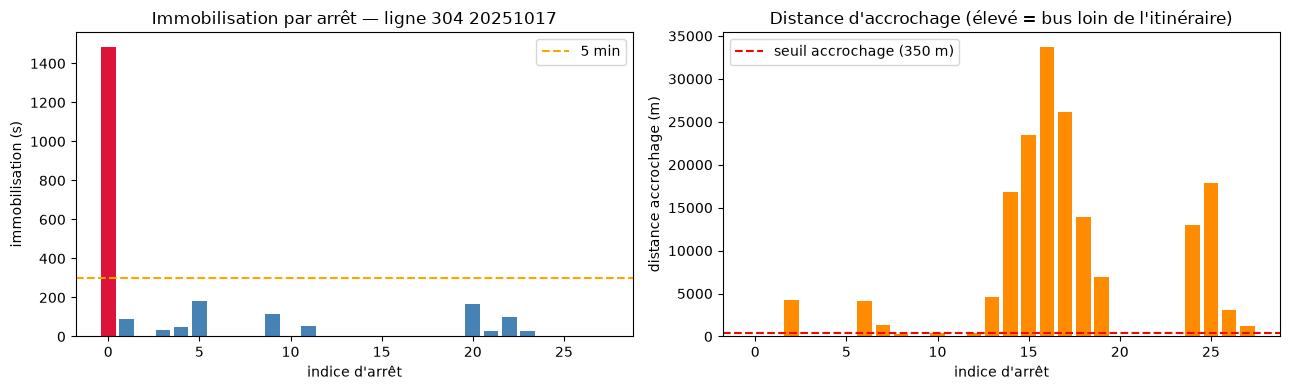

In [32]:
# Inspecter le trajet le plus anormal (LSTM)
worst_idx  = int(np.argmax(train_errors))
worst_keys = dict(zip(an.TRIP_KEYS, trip_ids[worst_idx]))
print(f'Trajet le plus anormal (LSTM) : {worst_keys}')
print(f'  erreur de reconstruction : {train_errors[worst_idx]:.5f}')

trip_rows = fa[
    (fa['day']     == worst_keys['day'])     &
    (fa['line']    == worst_keys['line'])    &
    (fa['societe'] == worst_keys['societe']) &
    (fa['bus']     == worst_keys['bus'])     &
    (fa['trip_id'] == worst_keys['trip_id'])
].sort_values('seq')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(trip_rows['seq'], trip_rows['dwell_s'].fillna(0),
          color=['crimson' if d > 300 else 'steelblue' for d in trip_rows['dwell_s'].fillna(0)])
ax[0].axhline(300, color='orange', ls='--', label='5 min')
ax[0].set_xlabel("indice d'arrêt"); ax[0].set_ylabel('immobilisation (s)')
ax[0].set_title(f'Immobilisation par arrêt — ligne {worst_keys["line"]} {worst_keys["day"]}')
ax[0].legend()

ax[1].bar(trip_rows['seq'], trip_rows['dist_m'].fillna(0), color='darkorange')
ax[1].axhline(350, color='red', ls='--', label='seuil accrochage (350 m)')
ax[1].set_xlabel("indice d'arrêt"); ax[1].set_ylabel('distance accrochage (m)')
ax[1].set_title("Distance d'accrochage (élevé = bus loin de l'itinéraire)")
ax[1].legend()
plt.tight_layout(); plt.show()

In [33]:
# Sauvegarder les modèles
joblib.dump({'model': if_model, 'mean': if_mean, 'std': if_std},
            MODELS_DIR / 'anomaly_if.pkl')
print('✓  anomaly_if.pkl')

torch.save(lstm_model.state_dict(), MODELS_DIR / 'anomaly_lstm.pt')
print('✓  anomaly_lstm.pt')

joblib.dump({'threshold': threshold, 'threshold_pct': LSTM_THRESHOLD_PCT},
            MODELS_DIR / 'anomaly_lstm_threshold.pkl')
print('✓  anomaly_lstm_threshold.pkl')

print(f'\nTous les modèles sauvegardés dans : {MODELS_DIR}')

✓  anomaly_if.pkl
✓  anomaly_lstm.pt
✓  anomaly_lstm_threshold.pkl

Tous les modèles sauvegardés dans : c:\Users\deadx\OneDrive\Desktop\winicari\models\anomaly
